# 4.6 暂退法（Dropout）

暂退法在训练时随机把一部分隐藏单元的输出置零，从而减少神经元之间的过度依赖，是多层感知机中常见的正则化方法。

原教材：[4.6 暂退法（Dropout）](https://zh.d2l.ai/chapter_multilayer-perceptrons/dropout.html)

> 本章代码只使用 PyTorch、Torchvision、Matplotlib 等基础库，不依赖 `d2l`。

## 学习目标

1. 理解 Dropout 的随机掩码和缩放规则；
2. 从零实现 Dropout；
3. 掌握 `nn.Dropout` 及其训练/评估模式；
4. 能在多层感知机中正确安排 Dropout 的位置。

## 4.6.1 Dropout 的计算

设丢弃概率为 $p$，对激活值 $h$ 的处理为

$$h'=\begin{cases}0,&\text{概率 }p,\\\frac{h}{1-p},&\text{概率 }1-p.\end{cases}$$

除以 $1-p$ 可以保持期望不变：$\mathbb E[h']=h$。Dropout 只在训练阶段制造随机扰动；评估和预测时必须关闭，使用完整网络。

In [1]:
import sys  # 判断操作系统，以选择稳定的数据加载进程数
from pathlib import Path  # 统一管理数据与图片路径

import matplotlib.pyplot as plt  # 绘制训练指标曲线
import torch  # 提供张量计算、自动微分和优化器
import torchvision  # 提供 Fashion-MNIST 数据集
from torch import nn  # 提供网络层、Dropout 和损失函数
from torch.utils.data import DataLoader  # 将数据集组织成小批量迭代器
from torchvision import transforms  # 将图片转换为 PyTorch 张量

try:  # 尝试判断当前环境是否为 Google Colab
    from google.colab import drive  # 导入 Colab 的云盘挂载工具
    drive.mount('/content/drive')  # 挂载用户的“我的云端硬盘”
    project_root = Path('/content/drive/MyDrive/d2l_learning')  # 指向云盘中的项目根目录
except ImportError:  # 本地环境没有 google.colab 时进入此分支
    project_root = Path.cwd().parent if Path.cwd().name == 'Chapter_4' else Path.cwd()  # 推断本地项目根目录

data_root = project_root / 'data'  # 将数据保存在项目的 data 目录中
figure_dir = project_root / 'Chapter_4' / 'images'  # 设置第 4 章图片保存目录
figure_dir.mkdir(parents=True, exist_ok=True)  # 创建图片目录且允许目录已经存在
torch.manual_seed(42)  # 固定 CPU 随机种子以复现实验结果
device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))  # 优先选择 CUDA，其次选择 MPS，最后使用 CPU
print('计算设备:', device)  # 输出实际采用的训练设备

计算设备: cpu


## 4.6.2 从零实现 Dropout

边界情况需要单独处理：$p=0$ 时原样返回；$p=1$ 时全部置零。一般情况下先采样伯努利掩码，再执行缩放。

In [2]:
def dropout_layer(X, dropout):  # 定义从零实现的 Dropout 函数
    assert 0 <= dropout <= 1  # 检查丢弃概率是否位于合法区间 [0,1]
    if dropout == 1:  # 判断是否需要丢弃所有元素
        return torch.zeros_like(X)  # 返回与输入同形状的全零张量
    if dropout == 0:  # 判断是否完全不执行丢弃
        return X  # 原样返回输入张量
    mask = (torch.rand_like(X) > dropout).to(X.dtype)  # 采样保留概率为 1-dropout 的 0/1 掩码
    return mask * X / (1.0 - dropout)  # 丢弃元素并缩放保留值以维持输出期望

X = torch.arange(16, dtype=torch.float32, device=device).reshape(2, 8)  # 在计算设备上构造两行八列测试张量
print('输入：\n', X)  # 输出未经 Dropout 处理的原始张量
print('dropout=0：\n', dropout_layer(X, 0.0))  # 验证丢弃概率为 0 时输入保持不变
print('dropout=0.5：\n', dropout_layer(X, 0.5))  # 观察约一半元素被随机置零且其余元素放大
print('dropout=1：\n', dropout_layer(X, 1.0))  # 验证丢弃概率为 1 时输出全为零

输入：
 tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
dropout=0：
 tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
dropout=0.5：
 tensor([[ 0.,  2.,  0.,  6.,  0., 10.,  0., 14.],
        [16.,  0., 20., 22., 24., 26., 28.,  0.]])
dropout=1：
 tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


## 4.6.3 从零构建含 Dropout 的 MLP

Dropout 通常放在隐藏层激活函数之后。输出层一般不使用 Dropout，因为我们希望分类 logits 由全部最终隐藏特征稳定产生。

In [3]:
class ScratchDropoutMLP(nn.Module):  # 定义使用自制 Dropout 的多层感知机
    def __init__(self, num_inputs=784, num_hiddens1=256, num_hiddens2=256, num_outputs=10, dropout1=0.2, dropout2=0.5):  # 接收网络宽度和丢弃概率
        super().__init__()  # 初始化 nn.Module 基类以启用参数登记功能
        self.num_inputs = num_inputs  # 保存展平后输入特征数
        self.dropout1 = dropout1  # 保存第一隐藏层的丢弃概率
        self.dropout2 = dropout2  # 保存第二隐藏层的丢弃概率
        self.linear1 = nn.Linear(num_inputs, num_hiddens1)  # 创建输入层到第一隐藏层的全连接变换
        self.linear2 = nn.Linear(num_hiddens1, num_hiddens2)  # 创建第一隐藏层到第二隐藏层的全连接变换
        self.linear3 = nn.Linear(num_hiddens2, num_outputs)  # 创建第二隐藏层到输出层的全连接变换

    def forward(self, X):  # 定义模型从输入到 logits 的前向传播
        X = X.reshape(-1, self.num_inputs)  # 将 [B,1,28,28] 图片展平为 [B,784]
        H1 = torch.relu(self.linear1(X))  # 计算第一隐藏层的线性变换和 ReLU 激活
        if self.training:  # 仅在 model.train() 模式下执行随机丢弃
            H1 = dropout_layer(H1, self.dropout1)  # 对第一隐藏层应用自制 Dropout
        H2 = torch.relu(self.linear2(H1))  # 计算第二隐藏层的线性变换和 ReLU 激活
        if self.training:  # 再次检查当前是否处于训练模式
            H2 = dropout_layer(H2, self.dropout2)  # 对第二隐藏层应用自制 Dropout
        return self.linear3(H2)  # 输出未经过 softmax 的 10 类 logits

scratch_net = ScratchDropoutMLP().to(device)  # 实例化自制 Dropout 网络并移动到计算设备
shape_test = torch.randn(4, 1, 28, 28, device=device)  # 在计算设备上构造 4 张随机图片
scratch_net.train()  # 切换到训练模式以启用 Dropout
train_output1 = scratch_net(shape_test)  # 第一次前向传播会采样一组随机掩码
train_output2 = scratch_net(shape_test)  # 第二次前向传播会重新采样随机掩码
scratch_net.eval()  # 切换到评估模式以关闭 Dropout
eval_output1 = scratch_net(shape_test)  # 第一次评估前向传播使用完整网络
eval_output2 = scratch_net(shape_test)  # 第二次评估前向传播仍使用相同完整网络
print('训练模式两次输出相同:', torch.allclose(train_output1, train_output2))  # 验证训练输出因随机掩码而通常不同
print('评估模式两次输出相同:', torch.allclose(eval_output1, eval_output2))  # 验证评估输出确定且相同

训练模式两次输出相同: False
评估模式两次输出相同: True


## 4.6.4 使用 `nn.Dropout` 的简洁实现

`nn.Dropout(p)` 已经实现随机掩码、期望缩放和训练/评估模式切换。只要把它放进 `nn.Sequential`，调用 `net.train()` 和 `net.eval()` 时就会自动改变行为。

In [4]:
dropout1, dropout2 = 0.2, 0.5  # 设置两个隐藏层各自的丢弃概率
net = nn.Sequential(  # 按数据流顺序组合所有网络层
    nn.Flatten(),  # 将每张 28×28 图片展平为长度 784 的向量
    nn.Linear(784, 256),  # 创建输入层到第一隐藏层的全连接变换
    nn.ReLU(),  # 对第一隐藏层应用 ReLU 激活
    nn.Dropout(dropout1),  # 在训练时随机丢弃第一隐藏层的部分输出
    nn.Linear(256, 256),  # 创建第一隐藏层到第二隐藏层的全连接变换
    nn.ReLU(),  # 对第二隐藏层应用 ReLU 激活
    nn.Dropout(dropout2),  # 在训练时随机丢弃第二隐藏层的部分输出
    nn.Linear(256, 10),  # 将第二隐藏层映射为 10 类 logits
)  # 完成含两个 Dropout 层的 MLP 定义

def init_weights(module):  # 定义供 net.apply 调用的参数初始化函数
    if isinstance(module, nn.Linear):  # 只处理拥有权重和偏置的全连接层
        nn.init.normal_(module.weight, mean=0.0, std=0.01)  # 将权重初始化为小正态随机数
        nn.init.zeros_(module.bias)  # 将所有偏置初始化为 0

net.apply(init_weights)  # 递归访问网络各层并初始化所有 Linear 参数
net.to(device)  # 将网络的全部参数和缓冲区移动到计算设备
print(net)  # 输出完整网络结构以检查 Dropout 的位置

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)


## 4.6.5 数据与训练

下面仍使用 Fashion-MNIST。训练时必须调用 `model.train()` 启用 Dropout，验证时调用 `model.eval()` 关闭 Dropout。

In [5]:
batch_size = 256  # 设置每个小批量包含 256 张图片
num_workers = 0 if sys.platform.startswith('win') else 2  # Windows 使用单进程加载以提高兼容性
train_dataset = torchvision.datasets.FashionMNIST(  # 创建 Fashion-MNIST 训练集对象
    root=data_root, train=True, transform=transforms.ToTensor(), download=True  # 下载训练集并把图片转为张量
)  # 完成训练数据集配置
test_dataset = torchvision.datasets.FashionMNIST(  # 创建 Fashion-MNIST 测试集对象
    root=data_root, train=False, transform=transforms.ToTensor(), download=True  # 下载测试集并把图片转为张量
)  # 完成测试数据集配置
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)  # 打乱训练集并按批读取
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)  # 保持测试集顺序并按批读取
print(len(train_dataset), len(test_dataset))  # 输出训练集与测试集的样本数

60000 10000


In [6]:
def evaluate_accuracy(model, data_iter):  # 定义模型在指定数据集上的准确率评估函数
    model.eval()  # 切换到评估模式并自动关闭 nn.Dropout
    correct, total = 0, 0  # 初始化预测正确数与样本总数
    with torch.no_grad():  # 关闭梯度记录以节省评估资源
        for X, y in data_iter:  # 逐批读取测试图片与真实标签
            X, y = X.to(device), y.to(device)  # 将当前批次的特征和标签移动到计算设备
            predictions = model(X).argmax(dim=1)  # 计算 logits 并选取分数最大的类别
            correct += int((predictions == y).sum())  # 累加当前批次预测正确数
            total += y.numel()  # 累加当前批次样本数
    return correct / total  # 返回整个数据集上的分类准确率

def train_model(model, train_iter, test_iter, loss_fn, optimizer, num_epochs):  # 定义含 Dropout 的完整训练流程
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}  # 创建保存每轮指标的字典
    for epoch in range(num_epochs):  # 重复遍历训练集指定轮数
        model.train()  # 切换到训练模式并自动启用 nn.Dropout
        loss_sum, correct, total = 0.0, 0, 0  # 重置本轮累计损失、正确数和样本数
        for X, y in train_iter:  # 逐个小批量训练模型
            X, y = X.to(device), y.to(device)  # 将当前训练批次移动到计算设备
            optimizer.zero_grad()  # 清除上一批次保留在参数上的梯度
            logits = model(X)  # 前向传播并在隐藏层随机执行 Dropout
            loss = loss_fn(logits, y)  # 计算当前批次的平均交叉熵损失
            loss.backward()  # 反向传播计算模型参数梯度
            optimizer.step()  # 根据梯度更新所有可训练参数
            loss_sum += loss.item() * y.numel()  # 将批平均损失转换为损失总和后累计
            correct += int((logits.argmax(dim=1) == y).sum())  # 累加当前批次预测正确数
            total += y.numel()  # 累加当前批次样本数
        history['train_loss'].append(loss_sum / total)  # 计算并记录本轮平均训练损失
        history['train_acc'].append(correct / total)  # 计算并记录本轮训练准确率
        history['test_acc'].append(evaluate_accuracy(model, test_iter))  # 关闭 Dropout 后评估并记录测试准确率
        print(f"epoch {epoch + 1:2d}: loss {history['train_loss'][-1]:.4f}, "  # 生成轮次和损失文本
              f"train acc {history['train_acc'][-1]:.3f}, test acc {history['test_acc'][-1]:.3f}")  # 补充并输出准确率文本
    return history  # 返回全部训练历史

learning_rate, num_epochs = 0.1, 10  # 设置 SGD 学习率和训练轮数
loss_fn = nn.CrossEntropyLoss()  # 创建适用于多分类 logits 的交叉熵损失函数
optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate)  # 使用网络自动登记的参数创建 SGD 优化器
history = train_model(net, train_iter, test_iter, loss_fn, optimizer, num_epochs)  # 启动训练并保存指标历史

epoch  1: loss 1.7776, train acc 0.325, test acc 0.534
epoch  2: loss 0.8899, train acc 0.661, test acc 0.721
epoch  3: loss 0.6938, train acc 0.748, test acc 0.750
epoch  4: loss 0.6043, train acc 0.787, test acc 0.791
epoch  5: loss 0.5459, train acc 0.808, test acc 0.819
epoch  6: loss 0.5041, train acc 0.822, test acc 0.820
epoch  7: loss 0.4748, train acc 0.832, test acc 0.800
epoch  8: loss 0.4525, train acc 0.840, test acc 0.840
epoch  9: loss 0.4384, train acc 0.844, test acc 0.833
epoch 10: loss 0.4201, train acc 0.850, test acc 0.848


图片已保存到：f:\CODE\d2l_learning\Chapter_4\images\4.6_dropout_training.png


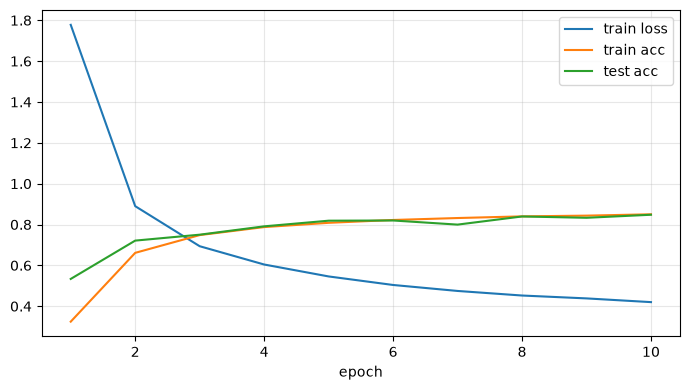

In [7]:
epochs = range(1, num_epochs + 1)  # 生成从 1 开始的训练轮次横坐标
fig, axis = plt.subplots(figsize=(7, 4))  # 创建用于绘制训练指标的画布
axis.plot(epochs, history['train_loss'], label='train loss')  # 绘制训练损失曲线
axis.plot(epochs, history['train_acc'], label='train acc')  # 绘制训练准确率曲线
axis.plot(epochs, history['test_acc'], label='test acc')  # 绘制测试准确率曲线
axis.set_xlabel('epoch')  # 设置横轴为训练轮次
axis.grid(alpha=0.3)  # 添加半透明网格辅助读数
axis.legend()  # 显示三条曲线对应的图例
plt.tight_layout()  # 自动调整画布边距
figure_path = figure_dir / '4.6_dropout_training.png'  # 生成图片的完整保存路径
fig.savefig(figure_path, dpi=160, bbox_inches='tight')  # 保存高清图片并裁掉多余白边
print(f'图片已保存到：{figure_path}')  # 输出图片保存位置
plt.show()  # 在 Notebook 中显示训练曲线

## 4.6.6 小结

- Dropout 在训练时随机屏蔽隐藏单元，并通过 $1/(1-p)$ 缩放保持输出期望；
- Dropout 通常放在隐藏层激活之后，不用于输出层；
- `model.train()` 启用 Dropout，`model.eval()` 关闭 Dropout；
- 丢弃概率越大，正则化越强，但过大也会造成欠拟合。

## 4.6.7 练习与参考答案

1. **为什么保留的激活值要除以 $1-p$？** 因为每个元素被保留的概率是 $1-p$，缩放后输出期望仍等于原激活值。
2. **预测时为什么关闭 Dropout？** 预测需要稳定使用完整网络；若仍随机丢弃，同一输入会得到不稳定结果。
3. **忘记调用 `model.eval()` 会怎样？** Dropout 会继续随机置零，测试结果会随机波动且通常偏差更大。
4. **Dropout 概率越大越好吗？** 不是。概率过大会丢失过多信息，使优化困难并造成欠拟合。